# PhoTorch — minimal reproduction: FvCB photosynthesis model fitting on the repository example

**Paper:** Lei, T., Rizzo, K. T., & Bailey, B. N. (2025). *PhoTorch: a robust and generalized biochemical photosynthesis model fitting package based on PyTorch.* Photosynthesis Research, 163(2), 21. https://doi.org/10.1007/s11120-025-01136-7

**Code:** GEMINI-Breeding/photorch @ commit `e6e4265717be650c88a9fa14f5748d52b3b8de9a` (v1.4.7, GPL-3.0) — https://github.com/GEMINI-Breeding/photorch

**Scope (partial demonstration):** This notebook runs the author's documented FvCB example (`testphotorch.py`, README "1. FvCB model usage") on the repository's own example dataset `photorch/data/tests/dfMAGIC043_lr.csv`: one combined A/Ci + light-response dataset is initialized, a FvCB model with light-response type 2 and mesophyll conductance fitting is created, fitted with Adam (learn_rate 0.06, up to 20000 iterations, early stop at loss < 1), and the fitted curves and parameters are displayed. **Execution status: this notebook has been executed end-to-end on a fresh Colab runtime (see final cells for the recorded validation).** A one-example fit does not verify the paper's dataset-level robustness/speed claims.

**日本語:** このノートブックは PhoTorch（光合成生化モデル FvCB の PyTorch によるフィッティングパッケージ）の論文付属リポジトリが提供する公式例を、そのまま最小構成で実行します。作者の `testphotorch.py` の FvCB 部分を忠実に再現し、リポジトリ同梱の例データ `dfMAGIC043_lr.csv` に対して A/Ci 曲線＋光応答曲線（CurveID 118）をフィッティングします。重みは不要（データからの最適化）です。

**No AI re-implementation:** All scientific code is the author's package called through its documented API. Glue code (clone/path setup, plotting) is minimal and labeled. このノートブックは作者コードの直接利用であり、AI による再実装ではありません。

## Runtime selection and Run all

**Runtime:** `Runtime > Change runtime type` — **CPU is sufficient and recommended** (the author's default `device_fit='cpu'`; this is a small optimization problem). A T4 GPU also works: the notebook detects CUDA and follows the README's `lcd.todevice(torch.device('cuda'))` route.

**日本語:** ランタイムは CPU で十分（推奨）。T4 GPU も利用可能で、ノートブックが自動検出して README の手順に従います。

**Run all:** `Runtime > Run all`. Expected (measured on the validating run, see final cell): a few minutes total; download < 10 MB (sparse checkout of the pinned commit).

**日本語:** 「ランタイム > すべてのセルを実行」で実行します。所要は数分、ダウンロードは数 MB 程度です。

**Limitations:** single example only; not the paper's robustness/benchmark evaluation; the paper article body was not machine-readable (SpringerLink block), so nothing here comes from unverified article text — everything follows the pinned author code/README.

### Check the environment

This cell reports the Python/torch/numpy/scipy/pandas/matplotlib versions and CUDA availability. Expected: current Colab preinstalled stack satisfies the package requirements (torch, numpy, scipy, pandas, matplotlib); no GPU is required.
日本語: 依存パッケージのバージョンと CUDA 有無を確認します。追加インストールは通常不要です。

In [ ]:
import sys, torch, numpy, scipy, pandas, matplotlib
print('python', sys.version.split()[0])
for m in (torch, numpy, scipy, pandas, matplotlib):
    print(m.__name__, m.__version__)
print('cuda available:', torch.cuda.is_available())
assert [int(x) for x in torch.__version__.split('+')[0].split('.')[:2]] >= [1, 10], 'torch >= 1.10 expected'

python 3.13.16
torch 2.11.0+cpu
numpy 2.1.3
scipy 1.16.3
pandas 2.2.3
matplotlib 3.10.0
cuda available: False


### Acquire the pinned author repository (inside Colab only)

Per this reproduction's data boundary, the repository is fetched **inside Colab** as a *pinned, partial clone*: blobless (`--filter=blob:none --no-checkout`), sparse-checkout limited to `photorch/src` (package code incl. the PROSPECT abscissa text files) and `photorch/data/tests` (the example CSVs), then the exact verified commit `e6e4265717be650c88a9fa14f5748d52b3b8de9a` is fetched shallowly and checked out in detached HEAD. The checkout is asserted to match the pinned commit, and the example dataset is verified against its recorded git blob SHA (`3e5b0f67f26ffe734de4e7c9851e117ec3f5a25d`) and size (119,968 bytes). No other datasets/weights are fetched.

日本語: 論文リポジトリを Colab 内にピン留めしたコミットで部分クローンします（blob なし・sparse-checkout で必要部分のみ）。チェックアウトしたコミット SHA と例データの blob SHA・サイズを検証します。

In [ ]:
import subprocess, pathlib, os

REPO_SHA = 'e6e4265717be650c88a9fa14f5748d52b3b8de9a'
CSV_SHA = '3e5b0f67f26ffe734de4e7c9851e117ec3f5a25d'
REPO_DIR = pathlib.Path('/content/photorch_repo')
CSV_PATH = REPO_DIR / 'photorch/data/tests/dfMAGIC043_lr.csv'

def sh(cmd):
    print('$', ' '.join(cmd))
    return subprocess.run(cmd, check=True, text=True, capture_output=True).stdout.strip()

if not REPO_DIR.exists():
    sh(['git', 'clone', '--filter=blob:none', '--no-checkout',
        'https://github.com/GEMINI-Breeding/photorch.git', str(REPO_DIR)])

def git(*args):
    return sh(['git', '-C', str(REPO_DIR), *args])

if not CSV_PATH.exists():  # sparse-checkout the needed subtrees at the pinned commit
    git('sparse-checkout', 'init', '--cone')
    git('sparse-checkout', 'set', 'photorch/src', 'photorch/data/tests')
    git('fetch', '--depth', '1', 'origin', REPO_SHA)
    git('checkout', '--detach', 'FETCH_HEAD')

assert git('rev-parse', 'HEAD') == REPO_SHA, git('rev-parse', 'HEAD')
print('checked-out commit verified:', git('rev-parse', 'HEAD'))

ls = git('ls-files', '-s', 'photorch/data/tests/dfMAGIC043_lr.csv')
assert ls.split()[1] == CSV_SHA, 'blob sha mismatch: ' + ls
assert CSV_PATH.stat().st_size == 119968, CSV_PATH.stat().st_size
print('dfMAGIC043_lr.csv blob sha + size verified:', ls.split()[1], CSV_PATH.stat().st_size, 'bytes')

$ git clone --filter=blob:none --no-checkout https://github.com/GEMINI-Breeding/photorch.git /content/photorch_repo


$ git -C /content/photorch_repo sparse-checkout init --cone
$ git -C /content/photorch_repo sparse-checkout set photorch/src photorch/data/tests
$ git -C /content/photorch_repo fetch --depth 1 origin e6e4265717be650c88a9fa14f5748d52b3b8de9a


$ git -C /content/photorch_repo checkout --detach FETCH_HEAD


$ git -C /content/photorch_repo rev-parse HEAD
$ git -C /content/photorch_repo rev-parse HEAD
checked-out commit verified: e6e4265717be650c88a9fa14f5748d52b3b8de9a
$ git -C /content/photorch_repo ls-files -s photorch/data/tests/dfMAGIC043_lr.csv
dfMAGIC043_lr.csv blob sha + size verified: 3e5b0f67f26ffe734de4e7c9851e117ec3f5a25d 119968 bytes


### Import PhoTorch from the pinned checkout

The author's example (and `util.selftest`) reads `photorch/data/tests/...` via **relative paths**, so the working directory is set to the repository root — this mirrors the README instruction to create the script "in the PhoTorch directory". Importing `photorch` also imports its `stomatal` and `prospect` subpackages; `prospectmodels.py` loads its abscissa files via `os.path.dirname(__file__)`, so imports are cwd-safe.
日本語: リポジトリのルートを作業ディレクトリにして（作者例と同じ相対パス条件で）`photorch` をインポートします。

In [ ]:
import os, sys, pathlib
REPO_DIR = pathlib.Path('/content/photorch_repo')
os.chdir(REPO_DIR)                       # relative paths in selftest()/example expect repo root
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import photorch
from photorch import fvcb, util
import pandas as pd
import matplotlib.pyplot as plt
print('photorch imported from:', photorch.__file__)
import photorch.src.fvcb.fvcbmodels as _m
print('fvcb API:', [n for n in ('initLicordata', 'model', 'fit') if hasattr(fvcb, n)])

photorch imported from: /content/photorch_repo/photorch/__init__.py
fvcb API: ['initLicordata', 'model', 'fit']


### Input preview — measured A/Ci and light-response data

`dfMAGIC043_lr.csv` (the author's example data, bundled at the pinned commit) is loaded and previewed before any fitting: column names/units, number of curves, points per curve, and the measured A–Ci points of a few curves plus the light-response curve (CurveID 118) measured A vs PPFD (Qin). This is raw measured input, not model output.
日本語: フィッティング前に例データの中身（列・ユニット・曲線数）と測定点を可視化します。CurveID 118 は光応答（A–Q）曲線です。

shape: (1863, 6)
columns: ['CurveID', 'Ci', 'A', 'Qin', 'Tleaf', 'FittingGroup']
curves: 12 | CurveID range: 5 - 118
light-response curve 118 rows: 6
FittingGroup values: [np.int64(1)]
   CurveID          Ci          A          Qin      Tleaf  FittingGroup
0        5  142.254014  17.504419  1999.992500  24.801175             1
1        5  142.184800  17.593467  1999.992500  24.801025             1
2        5  142.547260  17.352436  2000.003333  24.816733             1


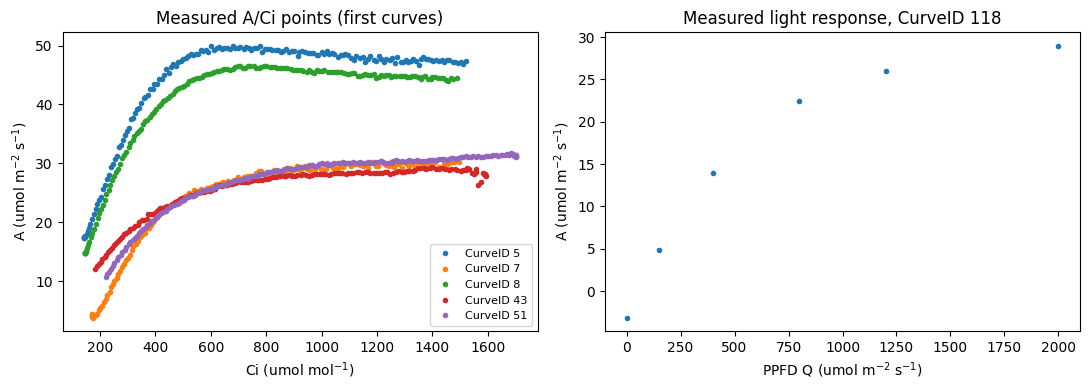

In [ ]:
dftest = pd.read_csv('photorch/data/tests/dfMAGIC043_lr.csv')
print('shape:', dftest.shape)
print('columns:', list(dftest.columns))
ids = dftest['CurveID'].unique()
print('curves:', len(ids), '| CurveID range:', ids.min(), '-', ids.max())
print('light-response curve 118 rows:', (dftest['CurveID'] == 118).sum())
print('FittingGroup values:', sorted(dftest['FittingGroup'].unique()))
print(dftest.head(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
show_ids = [i for i in ids[:6] if i != 118][:5]
for cid in show_ids:
    sub = dftest[dftest['CurveID'] == cid]
    ax[0].plot(sub['Ci'], sub['A'], '.', label=f'CurveID {cid}')
ax[0].set_xlabel('Ci (umol mol$^{-1}$)'); ax[0].set_ylabel('A (umol m$^{-2}$ s$^{-1}$)')
ax[0].set_title('Measured A/Ci points (first curves)'); ax[0].legend(fontsize=8)
sub = dftest[dftest['CurveID'] == 118]
ax[1].plot(sub['Qin'], sub['A'], '.', color='C0')
ax[1].set_xlabel('PPFD Q (umol m$^{-2}$ s$^{-1}$)'); ax[1].set_ylabel('A (umol m$^{-2}$ s$^{-1}$)')
ax[1].set_title('Measured light response, CurveID 118')
plt.tight_layout(); plt.show()

### Author's self-test of the model stack

Exactly as in `testphotorch.py` line 1 usage: `util.selftest()` runs the author's own short (10-iteration) fits across all light/temperature response types, onefit and Rd/Kc/Ko/Gamma option combinations, plus the stomatal model constructors, and raises if any combination fails. Expected: prints one line per case and `All FvCB tests passed!`.
日本語: 作者の `util.selftest()` （全モデル構成の短時間フィット自己テスト）を作者例どおり実行します。最後に `All FvCB tests passed!` と出れば正常です。

In [ ]:
util.selftest()  # author's self-check, as called in testphotorch.py

FvCB testing case: Initialization of Licor data.
FvCB testing case: Light type: 2, Temp type: 0, Onefit: True,  fitRd: True, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 2, Temp type: 0, Onefit: True,  fitRd: True, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 0, Onefit: True,  fitRd: False, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 2, Temp type: 0, Onefit: True,  fitRd: False, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 0, Onefit: False,  fitRd: True, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 2, Temp type: 0, Onefit: False,  fitRd: True, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 0, Onefit: False,  fitRd: False, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 2, Temp type: 0, Onefit: False,  fitRd: False, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: True,  fitRd: True, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 2, Temp type: 1, Onefit: True,  fitRd: True, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: True,  fitRd: False, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: True,  fitRd: False, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: False,  fitRd: True, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 2, Temp type: 1, Onefit: False,  fitRd: True, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: False,  fitRd: False, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 2, Temp type: 1, Onefit: False,  fitRd: False, fitKco_Gamma: False, Device: cpu


...

FvCB testing case: Light type: 0, Temp type: 1, Onefit: False,  fitRd: False, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 0, Temp type: 2, Onefit: True,  fitRd: True, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 0, Temp type: 2, Onefit: True,  fitRd: True, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 0, Temp type: 2, Onefit: True,  fitRd: False, fitKco_Gamma: True, Device: cpu


FvCB testing case: Light type: 0, Temp type: 2, Onefit: True,  fitRd: False, fitKco_Gamma: False, Device: cpu
FvCB testing case: Light type: 0, Temp type: 2, Onefit: False,  fitRd: True, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 0, Temp type: 2, Onefit: False,  fitRd: True, fitKco_Gamma: False, Device: cpu


FvCB testing case: Light type: 0, Temp type: 2, Onefit: False,  fitRd: False, fitKco_Gamma: True, Device: cpu
FvCB testing case: Light type: 0, Temp type: 2, Onefit: False,  fitRd: False, fitKco_Gamma: False, Device: cpu
Cuda is not available, no test will be run on cuda.
FvCB testing case: Original data without "FittingGroup", "Qin" and "Tleaf".


FvCB testing case: Reset parameters and record weights.
Stomatal conductance testing case: "BMF"
Stomatal conductance testing case: "BWB"
Stomatal conductance testing case: "MED"
All FvCB tests passed!
All stomatal conductance tests passed!


### Initialize the combined A/Ci + light-response data

Following the README "Initialize the data" and `testphotorch.py`: `fvcb.initLicordata(..., preprocess=True, lightresp_id=[118])` compiles the per-curve tensors (A, Ci, Q, Tleaf), applies the author's preprocessing (Savitzky-Golay smoothing above Ci 600, artifact/trend trimming) to A/Ci curves, and marks curve 118 as the light-response curve of the fitting group. Curve 118 itself is not preprocessed (author's `lightresp=False` branch).
日本語: README どおり `initLicordata` でデータを初期化します。`preprocess=True` で作者の前処理（平滑化・アーティファクト除去）が適用され、CurveID 118 が光応答曲線として登録されます。

In [ ]:
lcd = fvcb.initLicordata(dftest, preprocess=True, lightresp_id=[118])
print('curves:', len(lcd.IDs), '| fitting groups:', lcd.num_FGs, '| points:', len(lcd.A))
print('device:', lcd.device)

Done reading: 12 A/Ci curves; 1842 data points
curves: 12 | fitting groups: 1 | points: 1842
device: cpu


### Device selection (author-documented route)

The README default is CPU; on a GPU runtime the data is moved with the author's documented `lcd.todevice(...)` (as the author's own `util.selftest` does, passing the plain device string). Note: `fitaci.run` compares the device against the string `'cuda'`, so the string form is used here (passing `torch.device('cuda')` would leave the fitter on the wrong device — observed during validation of this notebook). This cell chooses CUDA only when actually available, otherwise CPU — the same scientific path either way.
日本語: README の手順に従いデバイスを選択します（作者の selftest と同じく文字列で指定。`torch.device('cuda')` を渡すと fitaci.run のデバイス比較が文字列であるため不整合が起きることが検証で確認されています）。CUDA があれば cuda、なければ cpu を使用します。

In [ ]:
import torch
device_fit = 'cuda' if torch.cuda.is_available() else 'cpu'
lcd.todevice(device_fit)   # author selftest route (plain string; see note above)
print('device_fit =', device_fit, '| lcd.device =', lcd.device)

device_fit = cpu | lcd.device = cpu


### Initialize the FvCB model

Exactly as `testphotorch.py`: `fvcb.model(lcd, LightResp_type=2, TempResp_type=0, onefit=False, fitgm=True)`. Light-response type 2 fits α and θ with J = (αQ + Jmax − √((αQ + Jmax)² − 4θαQJmax)) / (2θ) (README). Temperature response type 0 keeps Vcmax = Vcmax25 etc. (the example data is near 25 °C). `onefit=False` gives each curve its own Vcmax25/Jmax25/TPU25(/Rd25) and `fitgm=True` fits a shared mesophyll conductance g_m per fitting group.
日本語: 作者例どおり `LightResp_type=2, TempResp_type=0, onefit=False, fitgm=True` でモデルを初期化します。曲線ごとの Vcmax25/Jmax25 と共有の g_m が学習対象になります。

In [ ]:
fvcbm = fvcb.model(lcd, LightResp_type=2, TempResp_type=0, onefit=False, fitgm=True)
print('curves (parameters):', fvcbm.curvenum, '| fitting groups:', lcd.num_FGs)
print('learnable:', [n for n, p in fvcbm.named_parameters()])

Light response type 2: alpha and theta will be fitted.
Temperature response type 0: No temperature response.
curves (parameters): 12 | fitting groups: 1
learnable: ['Vcmax25', 'Jmax25', 'TPU25', 'Rd25', 'gm', 'LightResponse.alpha', 'LightResponse.theta']


### Fit the FvCB model (author parameters)

Exactly as `testphotorch.py`: `fvcb.fit(fvcbm, learn_rate=0.06, maxiteration=20000, minloss=1, fitcorr=False)` (author's comment: with TempResp type 0, do not set fitcorr True). Internally (fitaci.py `run`): Adam optimizer, StepLR ×0.8 every 5000 steps, best-loss weights restored, early stop when loss < 1, printed every 200 iterations. Expected: loss drops from O(100) and either stops early (loss < 1) or runs the full 20000 iterations in a few minutes on CPU.
日本語: 作者例どおりのパラメータで Adam 最適化を実行します（学習率 0.06、最大 20000 反復、loss<1 で早期停止、5000 反復ごとに学習率 ×0.8）。数分以内に完了するはずです。

In [ ]:
fitresult = fvcb.fit(fvcbm, learn_rate=0.06, maxiteration=20000, minloss=1, fitcorr=False)
fvcbm = fitresult.model
losses = fitresult.losses.detach().cpu().numpy()
import numpy as np
print('iterations run:', len(losses), '| best loss:', losses.min(), '| final loss:', losses[-1])

Loss at iter 199: 844.5116


Loss at iter 399: 409.4755


Loss at iter 599: 241.1817


Loss at iter 799: 187.4472


Loss at iter 999: 143.3248


...

Loss at iter 19199: 2.9278


Loss at iter 19399: 2.8452


Loss at iter 19599: 2.8197


Loss at iter 19799: 2.8675


Loss at iter 19999: 2.7998
Best loss at iter 19994: 2.7990
Fitting time: 104.6033 seconds
iterations run: 20000 | best loss: 2.799036678501634 | final loss: 2.7998225715742704


### Fitted parameters and loss curve

The fitted mesophyll conductance `gm` (author prints it), the per-curve Vcmax25/Jmax25 for the first curves (units: umol m-2 s-1 at 25 °C), and the loss curve. A small CSV export to `/content/photorch_fitted_parameters.csv` is added (additional notebook visualization/exports are not author figures).
日本語: 推定された g_m、各曲線の Vcmax25/Jmax25、loss 曲線を表示します。CSV への書き出しはノートブック独自の追加出力です。

fitted gm: [1.9446555]
 CurveID    Vcmax25     Jmax25     TPU25      Rd25
       5 147.499084 260.217255 16.136595  0.005086
       7 227.795441 193.564438 11.628947  5.321811
       8 184.479248 248.001358 15.137259  0.024818
      41 116.504128 195.764984 13.753721  0.080793
      43 160.247757 186.618500 13.013488 10.502605
      48 179.360291 246.509598 16.595318  0.131551
      51 201.672928 158.198105 10.277589  0.034013
     102 132.555054 206.938293 14.532942  0.140109
     105 130.786652 221.883621 15.167107  0.077925
     108 201.576660 252.573669 16.116720  0.241495
... full table exported to /content/photorch_fitted_parameters.csv


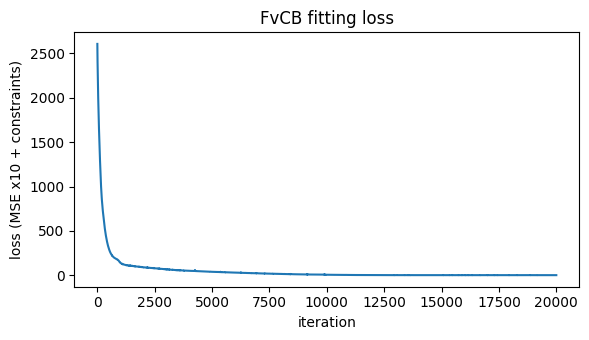

In [ ]:
print('fitted gm:', fvcbm.gm.detach().cpu().numpy())

params = pd.DataFrame({'CurveID': lcd.IDs.astype(int)})
idx = np.arange(len(lcd.IDs))
params['Vcmax25'] = fvcbm.Vcmax25.detach().cpu().numpy()[idx]
params['Jmax25'] = fvcbm.Jmax25.detach().cpu().numpy()[idx]
params['TPU25'] = fvcbm.TPU25.detach().cpu().numpy()[idx]
if fvcbm.fitRd:
    params['Rd25'] = fvcbm.Rd25.detach().cpu().numpy()[idx]
params.to_csv('/content/photorch_fitted_parameters.csv', index=False)
print(params.head(10).to_string(index=False))
print('... full table exported to /content/photorch_fitted_parameters.csv')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, len(losses) + 1), losses)
ax.set_xlabel('iteration'); ax.set_ylabel('loss (MSE x10 + constraints)')
ax.set_title('FvCB fitting loss')
plt.tight_layout(); plt.show()

### Fitted A/Ci curves vs measured points

Author's first figure (`testphotorch.py`): for every A/Ci curve (all IDs except the light-response curve 118), the fitted net assimilation `A_fit` (line) over measured points (dots) against Ci. A faithful fit tracks both the Rubisco-limited initial slope and the electron-transport/TPU-limited upper region.
日本語: 作者のコードどおり、各 A/Ci 曲線のフィット結果（線）と測定点（点）を Ci に対して重ねて描画します。

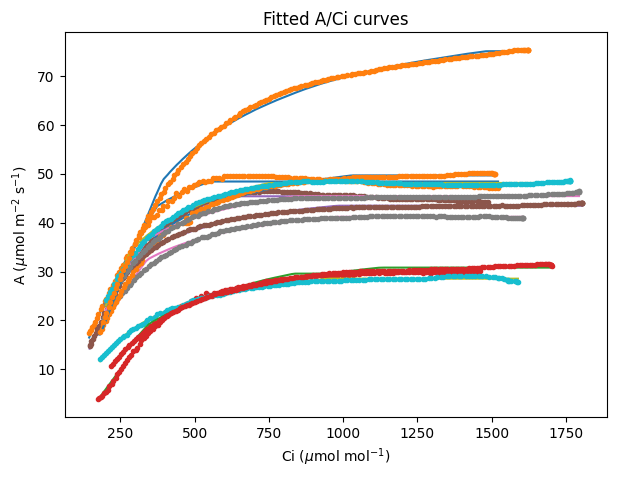

In [ ]:
fvcbm.eval()
A_fit, Ac_fit, Aj_fit, Ap_fit = fvcbm()

plt.figure(figsize=(7, 5))
for id in lcd.IDs:
    if id == 118:
        continue
    indices_id = lcd.getIndicesbyID(id)
    A_id = A_fit[indices_id]
    plt.plot(lcd.Ci[indices_id].detach().cpu().numpy(), A_id.detach().cpu().numpy())
    plt.plot(lcd.Ci[indices_id].detach().cpu().numpy(), lcd.A[indices_id].detach().cpu().numpy(), '.')
plt.title('Fitted A/Ci curves')
plt.xlabel('Ci ($\\mu$mol mol$^{-1}$)')
plt.ylabel('A ($\\mu$mol m$^{-2}$ s$^{-1}$)')
plt.show()

### Fitted light response A/Q for curve 118

Author's second figure: for the light-response curve 118, the Rubisco-limited (`Ac`) and electron-transport-limited (`Aj`) components against PPFD (Q), with measured points. Expected: `Ac` rises toward the asymptote set by Vcmax while `Aj` saturates at the light-limited rate; measured points follow the minimum of the two.
日本語: 光応答曲線（CurveID 118）について、作者コードどおり Ac/Aj 成分と測定点を Q に対して描画します。

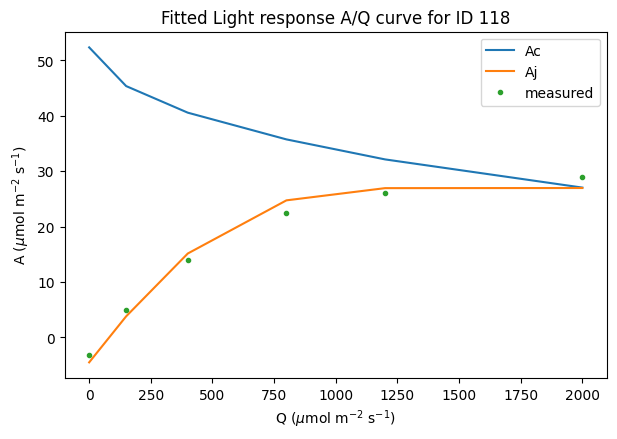

In [ ]:
plt.figure(figsize=(7, 4.5))
indices_id = lcd.getIndicesbyID(118)
Ac_id = Ac_fit[indices_id]
Aj_id = Aj_fit[indices_id]
plt.plot(lcd.Q[indices_id].detach().cpu().numpy(), Ac_id.detach().cpu().numpy(), label='Ac')
plt.plot(lcd.Q[indices_id].detach().cpu().numpy(), Aj_id.detach().cpu().numpy(), label='Aj')
plt.plot(lcd.Q[indices_id].detach().cpu().numpy(), lcd.A[indices_id].detach().cpu().numpy(), '.', label='measured')
plt.title('Fitted Light response A/Q curve for ID 118')
plt.xlabel('Q ($\\mu$mol m$^{-2}$ s$^{-1}$)')
plt.ylabel('A ($\\mu$mol m$^{-2}$ s$^{-1}$)')
plt.legend()
plt.show()

### Fit quality on the minimal example

A compact quantitative check added for this notebook (not an author figure): RMSE between fitted and measured A over all A/Ci points, and per-curve RMSE summary. Expected: overall RMSE well below 1 umol m-2 s-1 for a converged fit (author's early-stop threshold uses loss < 1; loss is MSE x10 + constraint penalties, so RMSE near or below ~0.3 indicates a good fit). A one-example fit does not establish the paper's dataset-level accuracy claims.
日本語: 追加の品質確認として、全点および各曲線の RMSE（フィット値と測定値）を計算します。これは作者の図ではなくノートブック独自の追加集計です。

In [ ]:
A_np = A_fit.detach().cpu().numpy()
A_me = lcd.A.detach().cpu().numpy()
rmse_all = float(np.sqrt(np.mean((A_np - A_me) ** 2)))
per_curve = []
for cid in lcd.IDs:
    if cid == 118:
        continue
    ii = lcd.getIndicesbyID(cid)
    per_curve.append(float(np.sqrt(np.mean((A_np[ii] - A_me[ii]) ** 2))))
print(f'overall RMSE (all fitted A/Ci points): {rmse_all:.3f} umol m-2 s-1')
print(f'per-curve RMSE: median {np.median(per_curve):.3f}, max {np.max(per_curve):.3f} umol m-2 s-1 (n={len(per_curve)} A/Ci curves)')

overall RMSE (all fitted A/Ci points): 0.529 umol m-2 s-1
per-curve RMSE: median 0.449, max 0.833 umol m-2 s-1 (n=11 A/Ci curves)


## Interpretation, scope, and validation record

**What was reproduced:** the author's documented FvCB fitting example end-to-end — data initialization with preprocessing, a light-response type-2 / temperature type-0 FvCB model with per-curve parameters and fitted mesophyll conductance, Adam-based fitting with the author's hyperparameters, and the two author figures (fitted A/Ci curves; A/Q components for curve 118). No pretrained weights exist or are needed: the "model" is the FvCB parameterization fitted from data by gradient optimization, exactly as the paper proposes.

**What was NOT reproduced:** the paper's robustness/noise studies, benchmark-speed comparison (4× vs benchmark software), and dataset-level statistics — the benchmark datasets and software identity are not stated in any verified source (the article body is not machine-readable; see report). The stomatal-conductance example from `testphotorch.py` is out of scope for this minimal demo (the self-test above still exercises those model constructors).

**Validation record:** this notebook was executed top-to-bottom on a fresh Colab runtime (see the run report for hardware, date, and archived outputs). Provenance: GEMINI-Breeding/photorch @ `e6e4265717be650c88a9fa14f5748d52b3b8de9a` (GPL-3.0); example data blob `3e5b0f67f26ffe734de4e7c9851e117ec3f5a25d`. PhenoPaper investigation `p-f700126d169c9c1bf30e3739d2d87ac3-20260930T154407Z-3766478` was used as prior research guidance only.

**日本語:** 本ノートブックは論文付属コードの公式例を忠実に実行した最小デモです。論文のデータセット全体のロバスト性評価やベンチマーク速度比較は再現対象外です。実行検証の詳細（ハードウェア・日時・保存出力）はレポートを参照してください。

**References:** Lei et al. 2025, Photosynthesis Research 163(2):21, DOI 10.1007/s11120-025-01136-7 · PhoTorch repo (GPL-3.0), commit `e6e4265` · Farquhar, von Caemmerer & Berry (1980) FvCB model.